# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Putri Prayesti
- Email: aeiprsty@gmail.com
- Id Dicoding: pppiiiy

## Persiapan

### Menyiapkan library yang dibutuhkan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Menyiapkan data yang akan digunakan

In [3]:
df = pd.read_csv("employee_data.csv")

df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [4]:
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   str    
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   str    
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   str    
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

In [6]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
df.isnull().sum()

EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [10]:
df["Attrition"].value_counts()

Attrition
0.0    879
1.0    179
Name: count, dtype: int64

In [11]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
0.0    83.081285
1.0    16.918715
Name: proportion, dtype: float64

## Data Preparation / Preprocessing

In [12]:
df_clean = df.dropna(subset=["Attrition"]).copy()

df_clean.shape

(1058, 35)

In [13]:
df_clean.isnull().sum().sum()

np.int64(0)

In [14]:
df_clean["Attrition"].value_counts()

Attrition
0.0    879
1.0    179
Name: count, dtype: int64

In [15]:
df_clean = df_clean.drop(columns=[
    "EmployeeId",
    "EmployeeCount",
    "Over18",
    "StandardHours"
])

In [16]:
df_clean.shape

(1058, 31)

In [17]:
X = df_clean.drop(columns=["Attrition"])
y = df_clean["Attrition"]

X.shape, y.shape

((1058, 30), (1058,))

In [18]:
categorical_cols = X.select_dtypes(include=["str"]).columns
numerical_cols = X.select_dtypes(exclude=["str"]).columns

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

## Modeling

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
X_train.shape, X_test.shape

((846, 30), (212, 30))

In [22]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

C:\Users\aeipr\AppData\Local\Temp\ipykernel_13344\1085263280.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [23]:
len(categorical_cols), len(numerical_cols)

(7, 23)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numerical_cols
        )
    ]
)

In [25]:
# Logistic Regression
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

c:\Users\aeipr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [26]:
# Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [27]:
y_pred_logistic = logistic_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [28]:
y_pred_logistic[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [29]:
y_pred_rf[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [30]:
logistic_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_balanced.fit(X_train, y_train)

c:\Users\aeipr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [31]:
logistic_balanced.fit(X_train, y_train)

c:\Users\aeipr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [32]:
y_pred_balanced = logistic_balanced.predict(X_test)

## Evaluation

In [33]:
# Evaluasi Logistic Regression
logistic_results = {
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic),
    "Recall": recall_score(y_test, y_pred_logistic),
    "F1-Score": f1_score(y_test, y_pred_logistic),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_model.predict_proba(X_test)[:, 1]
    )
}

# Evaluasi Random Forest
rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(
        y_test,
        rf_model.predict_proba(X_test)[:, 1]
    )
}

print("Logistic Regression")
for metric, value in logistic_results.items():
    print(f"{metric}: {value:.4f}")

print("\nRandom Forest")
for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression
Accuracy: 0.8491
Precision: 0.6000
Recall: 0.3333
F1-Score: 0.4286
ROC-AUC: 0.8351

Random Forest
Accuracy: 0.8491
Precision: 0.8333
Recall: 0.1389
F1-Score: 0.2381
ROC-AUC: 0.8012


In [34]:
balanced_results = {
    "Accuracy": accuracy_score(y_test, y_pred_balanced),
    "Precision": precision_score(y_test, y_pred_balanced),
    "Recall": recall_score(y_test, y_pred_balanced),
    "F1-Score": f1_score(y_test, y_pred_balanced),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_balanced.predict_proba(X_test)[:, 1]
    )
}

print("Logistic Regression (Balanced)")
for metric, value in balanced_results.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression (Balanced)
Accuracy: 0.7500
Precision: 0.3836
Recall: 0.7778
F1-Score: 0.5138
ROC-AUC: 0.8314


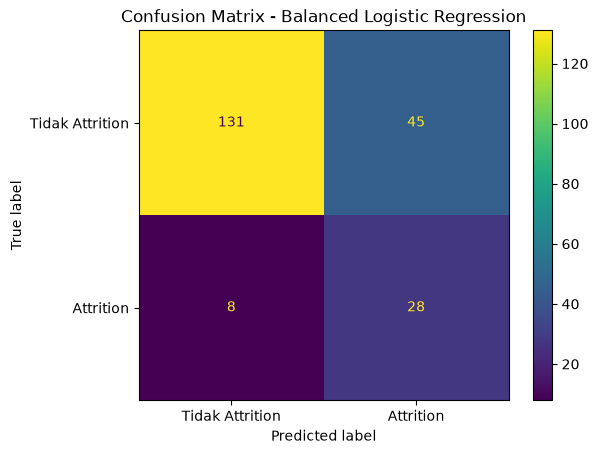

In [35]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["Tidak Attrition", "Attrition"]
)

disp.plot()
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

In [36]:
print("Logistic Regression:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nRandom Forest:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nLogistic Regression (Balanced):")
print(confusion_matrix(y_test, y_pred_balanced))

Logistic Regression:
[[168   8]
 [ 24  12]]

Random Forest:
[[175   1]
 [ 31   5]]

Logistic Regression (Balanced):
[[131  45]
 [  8  28]]


In [37]:
# Perbandingan performa model

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression (Balanced)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_balanced)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_balanced)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_balanced)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_balanced)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, logistic_balanced.predict_proba(X_test)[:, 1])
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.849057,0.600000,0.333333,0.428571,0.835069
1,Random Forest,0.849057,0.833333,0.138889,0.238095,0.801215
2,Logistic Regression (Balanced),0.750000,0.383562,0.777778,0.513761,0.831439


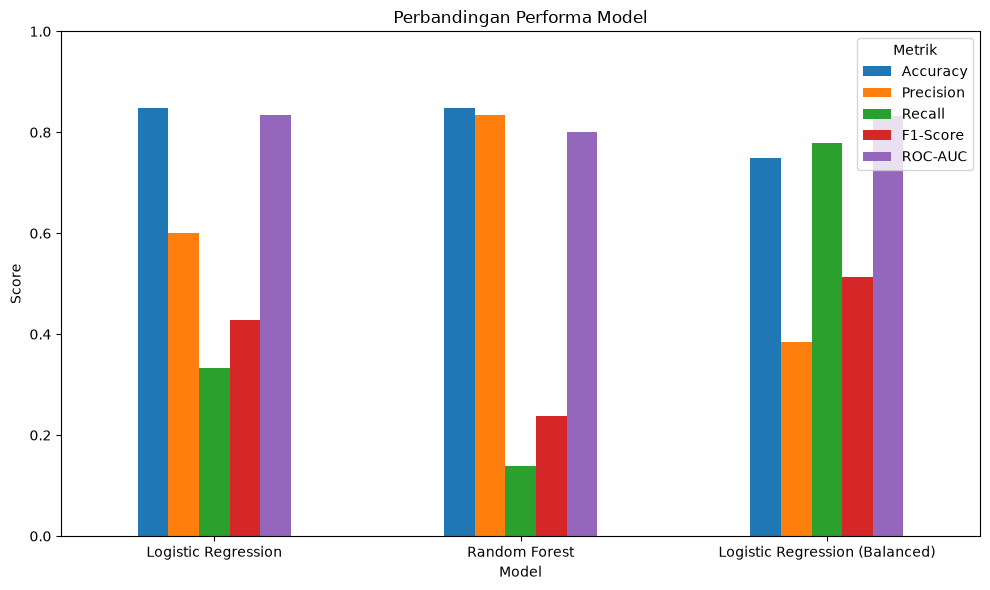

In [38]:
# Visualisasi perbandingan model

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrik")
plt.tight_layout()
plt.show()

In [39]:
def attrition_rate_by(column):
    result = df_clean.groupby(column)["Attrition"].agg(
        Total_Employees="count",
        Employees_Left="sum"
    )
    
    result["Attrition_Rate"] = (
        result["Employees_Left"] / result["Total_Employees"] * 100
    )
    
    return result.sort_values("Attrition_Rate", ascending=False)

In [40]:
attrition_rate_by("OverTime")

,Total_Employees,Employees_Left,Attrition_Rate
OverTime,,,
Yes,307,98.0,31.921824
No,751,81.0,10.785619


In [41]:
attrition_rate_by("JobRole")

,Total_Employees,Employees_Left,Attrition_Rate
JobRole,,,
Sales Representative,58,25.0,43.103448
Laboratory Technician,188,49.0,26.063830
Human Resources,30,6.0,20.000000
Research Scientist,214,38.0,17.757009
Sales Executive,232,39.0,16.810345
Healthcare Representative,88,8.0,9.090909
Manufacturing Director,107,7.0,6.542056
Manager,79,5.0,6.329114
Research Director,62,2.0,3.225806


In [42]:
attrition_rate_by("Department")

,Total_Employees,Employees_Left,Attrition_Rate
Department,,,
Sales,319,66.0,20.689655
Human Resources,38,6.0,15.789474
Research & Development,701,107.0,15.263909


In [43]:
attrition_rate_by("JobSatisfaction")

,Total_Employees,Employees_Left,Attrition_Rate
JobSatisfaction,,,
1,205,46.0,22.439024
3,318,62.0,19.496855
2,195,32.0,16.410256
4,340,39.0,11.470588


In [44]:
attrition_rate_by("WorkLifeBalance")

,Total_Employees,Employees_Left,Attrition_Rate
WorkLifeBalance,,,
1,56,18.0,32.142857
4,113,22.0,19.469027
2,251,45.0,17.928287
3,638,94.0,14.733542


In [46]:
df_clean["YearsAtCompany_Group"] = pd.cut(
    df_clean["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 20, float("inf")],
    labels=["0-2", "3-5", "6-10", "11-20", ">20"]
)

attrition_rate_by("YearsAtCompany_Group")

,Total_Employees,Employees_Left,Attrition_Rate
YearsAtCompany_Group,,,
0-2,247,74.0,29.959514
3-5,306,47.0,15.359477
6-10,325,43.0,13.230769
>20,50,6.0,12.000000
11-20,130,9.0,6.923077


In [47]:
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[17, 25, 35, 45, 60],
    labels=["18-25", "26-35", "36-45", "46-60"]
)

attrition_rate_by("Age_Group")

,Total_Employees,Employees_Left,Attrition_Rate
Age_Group,,,
18-25,92,35.0,38.043478
26-35,431,84.0,19.489559
46-60,207,24.0,11.594203
36-45,328,36.0,10.975610


In [48]:
df_clean["MonthlyIncome_Group"] = pd.qcut(
    df_clean["MonthlyIncome"],
    q=4,
    labels=["Q1 - Terendah", "Q2", "Q3", "Q4 - Tertinggi"]
)

attrition_rate_by("MonthlyIncome_Group")

,Total_Employees,Employees_Left,Attrition_Rate
MonthlyIncome_Group,,,
Q1 - Terendah,265,77.0,29.056604
Q2,264,44.0,16.666667
Q3,264,32.0,12.121212
Q4 - Tertinggi,265,26.0,9.811321


In [49]:
feature_names = logistic_balanced.named_steps["preprocessor"].get_feature_names_out()

coefficients = logistic_balanced.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance

,Feature,Coefficient
0,cat__BusinessTravel_Non-Travel,-0.265446
1,cat__BusinessTravel_Travel_Frequently,0.456737
2,cat__BusinessTravel_Travel_Rarely,0.010274
3,cat__Department_Human Resources,-0.012580
4,cat__Department_Research & Development,-0.035295
5,cat__Department_Sales,0.249440
6,cat__EducationField_Human Resources,-0.022319
7,cat__EducationField_Life Sciences,-0.129932
8,cat__EducationField_Marketing,0.216713
9,cat__EducationField_Medical,-0.077515


In [50]:
feature_importance_sorted = feature_importance.sort_values(
    "Coefficient",
    ascending=False
)

feature_importance_sorted.head(15)

,Feature,Coefficient
27,cat__OverTime_Yes,1.021020
25,cat__MaritalStatus_Single,0.583877
1,cat__BusinessTravel_Travel_Frequently,0.456737
41,num__PerformanceRating,0.385927
16,cat__JobRole_Laboratory Technician,0.292587
5,cat__Department_Sales,0.249440
11,cat__EducationField_Technical Degree,0.229584
13,cat__Gender_Male,0.224886
8,cat__EducationField_Marketing,0.216713
22,cat__JobRole_Sales Representative,0.197992


In [51]:
feature_importance_sorted.tail(15)

,Feature,Coefficient
14,cat__JobRole_Healthcare Representative,-0.090062
24,cat__MaritalStatus_Married,-0.092069
18,cat__JobRole_Manufacturing Director,-0.097750
42,num__RelationshipSatisfaction,-0.102111
50,num__YearsWithCurrManager,-0.105676
19,cat__JobRole_Research Director,-0.107080
36,num__JobSatisfaction,-0.112731
48,num__YearsInCurrentRole,-0.129485
7,cat__EducationField_Life Sciences,-0.129932
0,cat__BusinessTravel_Non-Travel,-0.265446


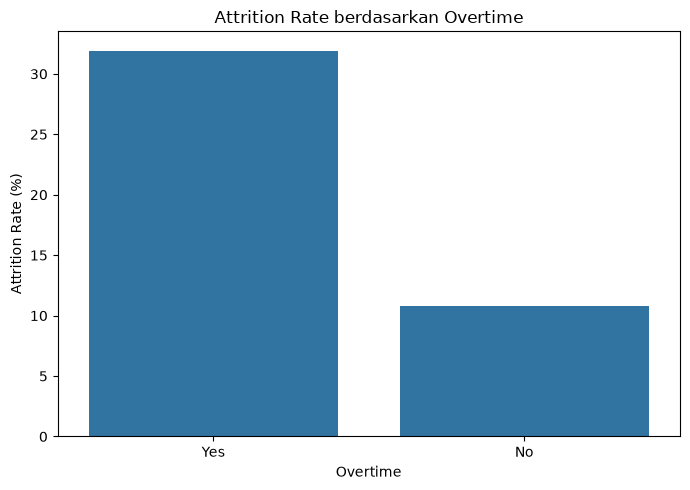

In [52]:
overtime_attrition = attrition_rate_by("OverTime")

plt.figure(figsize=(7, 5))

sns.barplot(
    x=overtime_attrition.index,
    y=overtime_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate berdasarkan Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

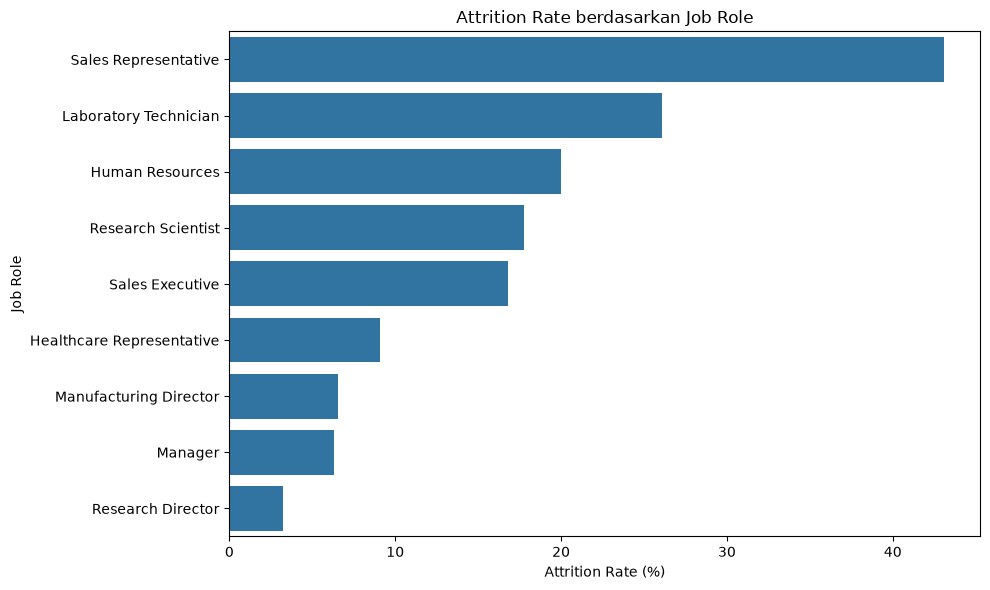

In [53]:
jobrole_attrition = attrition_rate_by("JobRole")

plt.figure(figsize=(10, 6))

sns.barplot(
    x=jobrole_attrition["Attrition_Rate"],
    y=jobrole_attrition.index
)

plt.title("Attrition Rate berdasarkan Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

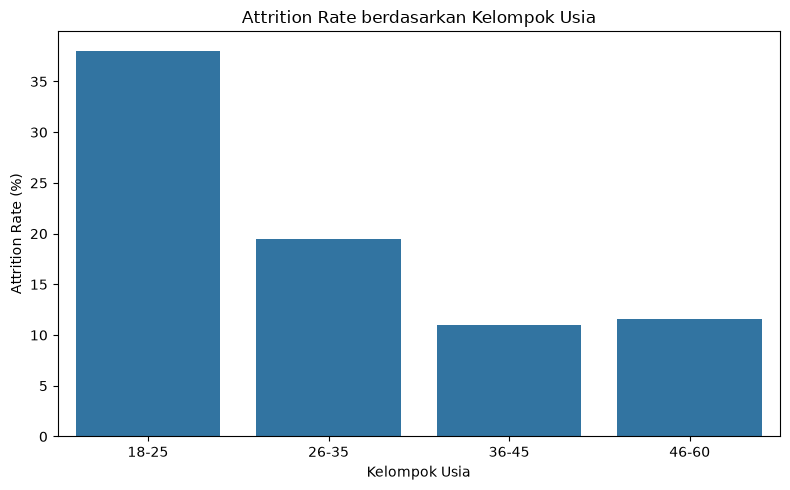

In [54]:
age_attrition = attrition_rate_by("Age_Group")

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_attrition.index,
    y=age_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate berdasarkan Kelompok Usia")
plt.xlabel("Kelompok Usia")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

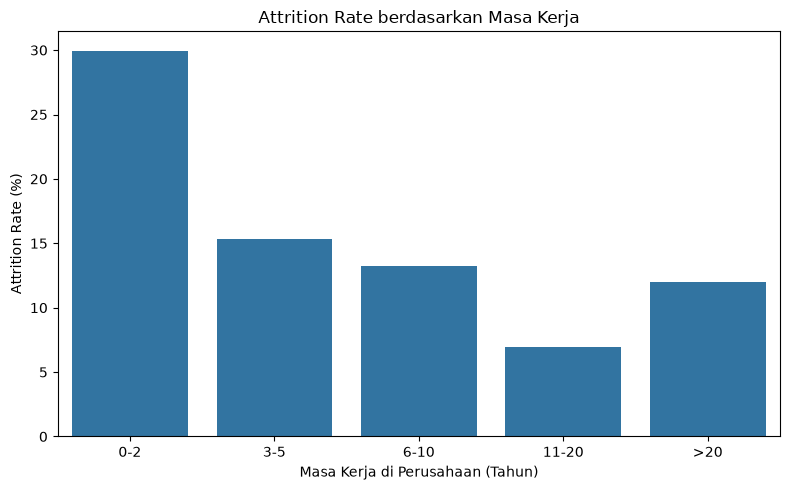

In [55]:
tenure_attrition = attrition_rate_by("YearsAtCompany_Group")

plt.figure(figsize=(8, 5))

sns.barplot(
    x=tenure_attrition.index,
    y=tenure_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate berdasarkan Masa Kerja")
plt.xlabel("Masa Kerja di Perusahaan (Tahun)")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

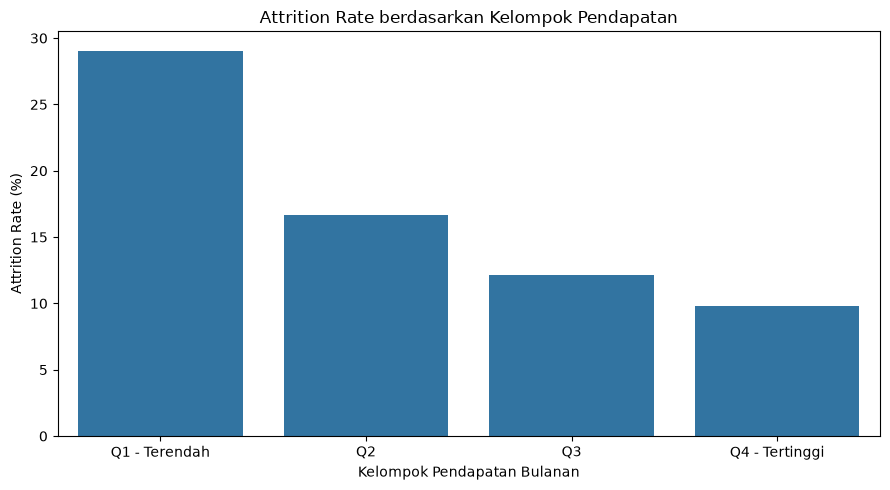

In [56]:
income_attrition = attrition_rate_by("MonthlyIncome_Group")

plt.figure(figsize=(9, 5))

sns.barplot(
    x=income_attrition.index,
    y=income_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate berdasarkan Kelompok Pendapatan")
plt.xlabel("Kelompok Pendapatan Bulanan")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

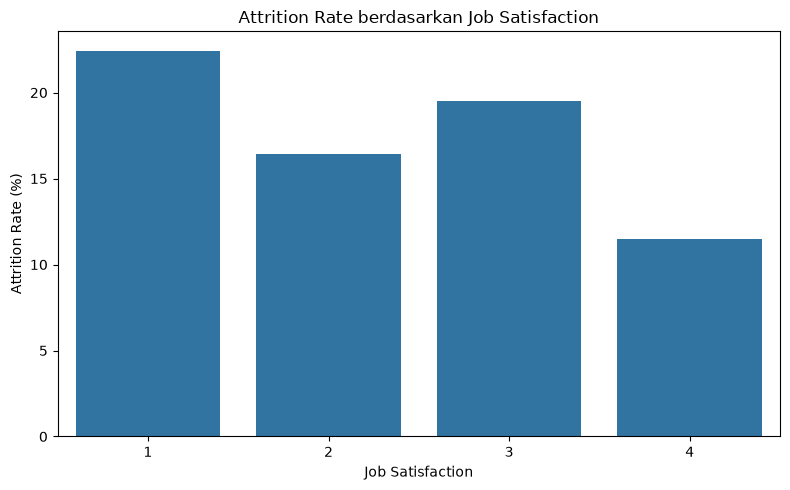

In [57]:
satisfaction_attrition = attrition_rate_by("JobSatisfaction")

plt.figure(figsize=(8, 5))

sns.barplot(
    x=satisfaction_attrition.index,
    y=satisfaction_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate berdasarkan Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

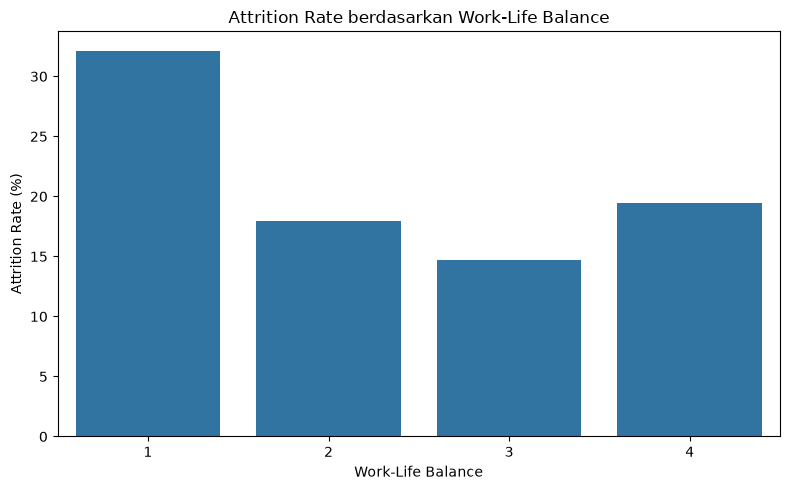

In [58]:
worklife_attrition = attrition_rate_by("WorkLifeBalance")

plt.figure(figsize=(8, 5))

sns.barplot(
    x=worklife_attrition.index,
    y=worklife_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate berdasarkan Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()